# Analyze A/B Test Results

**Author:** Sam Sepassi  
**Course:** Statistics for Data Analysis (nd588) — Course 4: Hypothesis Testing  
**Project:** Analyze A/B Test Results

---

## Project Scenario

An e-commerce company ran an A/B test to determine whether a **new landing page** increases conversions.
We analyze whether to launch the new page, keep the old, or run the test longer.

## Analysis Sections
1. Data Wrangling & Exploration
2. Probability & Baseline Conversion Rates
3. Simulation Under H₀
4. Z-Test for Proportions
5. Logistic Regression (with country)
6. Conclusions & Recommendation

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

np.random.seed(42)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded.")

Libraries loaded.


---
## Part I — Data Wrangling & Exploration


In [2]:
df = pd.read_csv('ab_data.csv')
print(f'Shape: {df.shape}')
print(f'\nNull values:\n{df.isnull().sum()}')
df.head()

Shape: (294478, 5)

Null values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48,control,old_page,0
1,804228,2017-01-12 08:01:45,control,old_page,0
2,661590,2017-01-11 16:55:06,treatment,new_page,0
3,853541,2017-01-08 18:28:03,treatment,new_page,0
4,864975,2017-01-21 01:52:26,control,old_page,1


In [3]:
print(f'Unique users: {df["user_id"].nunique()}')
print(f'Total rows:   {len(df)}')
print(f'Duplicate user_ids: {df["user_id"].duplicated().sum()}')
print('\nGroup counts:')
print(df['group'].value_counts())
print('\nLanding page counts:')
print(df['landing_page'].value_counts())

Unique users: 290584
Total rows:   294478
Duplicate user_ids: 3894

Group counts:
treatment    147239
control      147239
Name: group, dtype: int64

Landing page counts:
new_page    147239
old_page    147239
Name: landing_page, dtype: int64


In [4]:
# Find rows where group/page assignment is mismatched
mismatch = df[
    ((df['group'] == 'control')   & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
]
print(f'Mismatched rows: {len(mismatch)}')
print(mismatch.head())

Mismatched rows: 3893
   user_id                   timestamp      group landing_page  converted
1899   773192  2017-01-14 02:55:59  control     new_page          0
2893   905617  2017-01-20 14:57:11  treatment   old_page          0
7500   746755  2017-01-11 01:28:00  control     new_page          1


In [5]:
# Remove mismatched rows and duplicate user_ids
df_clean = df[
    ~(
        ((df['group'] == 'control')   & (df['landing_page'] == 'new_page')) |
        ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
    )
].copy()
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')
print(f'Clean shape: {df_clean.shape}')
print(df_clean['group'].value_counts())

Clean shape: (290584, 5)
treatment    145310
control      145274
Name: group, dtype: int64


---
## Part II — Probability & Baseline Conversion Rates


In [6]:
ctrl_df  = df_clean[df_clean['group'] == 'control']
treat_df = df_clean[df_clean['group'] == 'treatment']

p_ctrl = ctrl_df['converted'].mean()
p_trt  = treat_df['converted'].mean()
p_overall = df_clean['converted'].mean()

print(f'Overall conversion rate: {p_overall:.4f}')
print(f'Control   (old page): n={len(ctrl_df):,}  conversions={ctrl_df["converted"].sum():,}  rate={p_ctrl:.4f}')
print(f'Treatment (new page): n={len(treat_df):,}  conversions={treat_df["converted"].sum():,}  rate={p_trt:.4f}')
print(f'\nDifference (treatment - control): {p_trt - p_ctrl:.4f}')

Overall conversion rate: 0.1196
Control   (old page): n=145,274  conversions=17,489  rate=0.1204
Treatment (new page): n=145,310  conversions=17,264  rate=0.1188

Difference (treatment - control): -0.0016


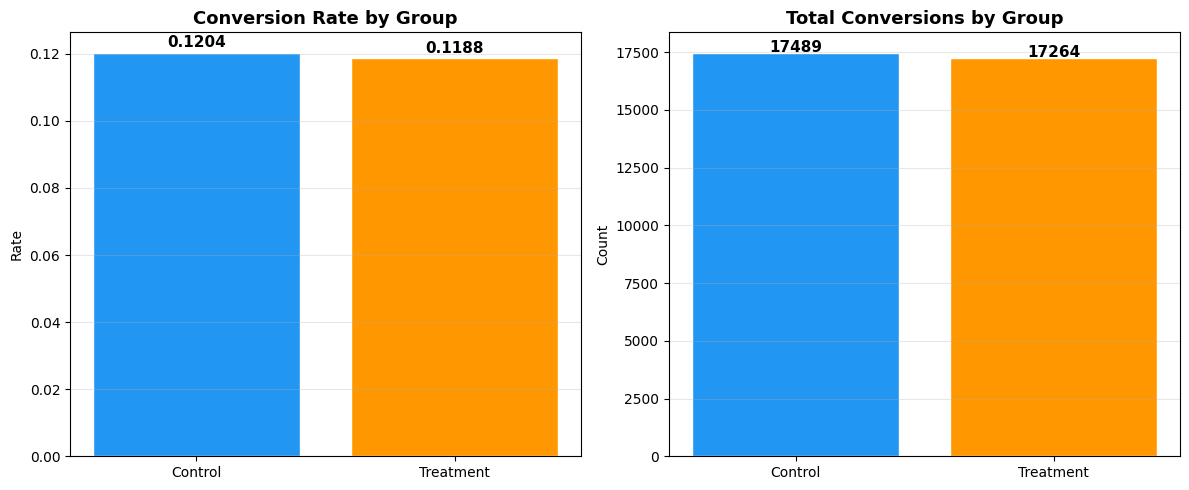

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
groups = ['Control (old page)', 'Treatment (new page)']
colors = ['#2196F3', '#FF9800']

axes[0].bar(groups, [p_ctrl, p_trt], color=colors, edgecolor='white')
axes[0].set_title('Conversion Rate by Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Conversion Rate'); axes[0].set_ylim(0, 0.15); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([p_ctrl, p_trt]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(groups, [ctrl_df['converted'].sum(), treat_df['converted'].sum()], color=colors, edgecolor='white')
axes[1].set_title('Total Conversions by Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Conversions'); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([ctrl_df['converted'].sum(), treat_df['converted'].sum()]):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part III — Simulation Under the Null Hypothesis

- **H₀:** p_new ≤ p_old (new page is no better)
- **H₁:** p_new > p_old (new page converts at higher rate)
- **α = 0.05**


In [8]:
p_null   = p_ctrl
obs_diff = p_trt - p_ctrl
print(f'Observed difference (treatment - control): {obs_diff:.4f}')
print(f'Simulating 10,000 experiments under H0...')

np.random.seed(42)
sim_diffs = np.array([
    np.random.binomial(len(treat_df), p_null) / len(treat_df) -
    np.random.binomial(len(ctrl_df),  p_null) / len(ctrl_df)
    for _ in range(10_000)
])

p_val_sim = (sim_diffs >= obs_diff).mean()
print(f'Simulation p-value: {p_val_sim:.4f}')
print(f'Reject H0? {"Yes" if p_val_sim < 0.05 else "No — fail to reject H0"}')

Observed difference (treatment - control): -0.0016
Simulating 10,000 experiments under H0...
Simulation p-value: 0.9029
Reject H0? No — fail to reject H0


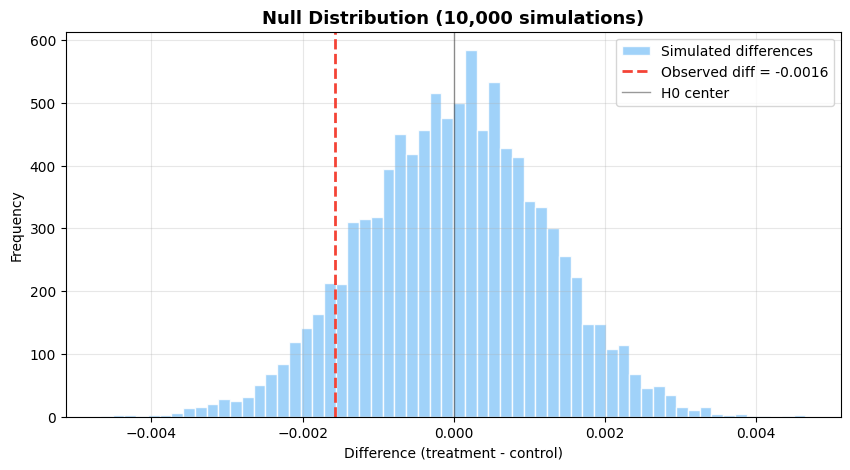

p-value (simulation): 0.9029


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sim_diffs, bins=60, color='#90CAF9', edgecolor='white', alpha=0.85, label='Simulated differences')
ax.axvline(obs_diff, color='#F44336', linewidth=2, linestyle='--', label=f'Observed diff = {obs_diff:.4f}')
ax.axvline(0, color='black', linewidth=1, alpha=0.4, label='H0 center')
ax.set_xlabel('Difference in Conversion Rate (treatment - control)', fontsize=11)
ax.set_ylabel('Frequency')
ax.set_title('Null Distribution of Differences (10,000 simulations)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'p-value (simulation): {p_val_sim:.4f}')

---
## Part IV — Z-Test for Proportions

Confirming the simulation result analytically.


In [10]:
n_c = len(ctrl_df);  x_c = int(ctrl_df['converted'].sum())
n_t = len(treat_df); x_t = int(treat_df['converted'].sum())

p_pool = (x_c + x_t) / (n_c + n_t)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
z      = (p_trt - p_ctrl) / se
p_one  = 1 - stats.norm.cdf(z)

print('Z-TEST FOR DIFFERENCE IN PROPORTIONS')
print(f'  Pooled p:             {p_pool:.4f}')
print(f'  Standard error:       {se:.6f}')
print(f'  Z-statistic:          {z:.4f}')
print(f'  p-value (one-tailed): {p_one:.4f}')
print()
print(f'  Critical z (alpha=0.05, one-tailed): {stats.norm.ppf(0.95):.4f}')
print(f'  Our z = {z:.4f} < 1.6449 — in non-rejection region')
print()
print(f'  Reject H0? {"Yes" if p_one < 0.05 else "No — fail to reject H0"}')

Z-TEST FOR DIFFERENCE IN PROPORTIONS
  Pooled p:             0.1196
  Standard error:       0.001204
  Z-statistic:          -1.3109
  p-value (one-tailed): 0.9051

  Critical z (alpha=0.05, one-tailed): 1.6449
  Our z = -1.3109 < 1.6449 — in non-rejection region

  Reject H0? No — fail to reject H0


---
## Part V — Logistic Regression

Modeling conversion probability including country as a control variable.


In [11]:
countries = pd.read_csv('countries.csv')
df_merged = df_clean.merge(countries, on='user_id', how='left')
df_merged['ab_page'] = (df_merged['group'] == 'treatment').astype(int)

dummies = pd.get_dummies(df_merged['country'], drop_first=True)
df_merged = pd.concat([df_merged, dummies], axis=1)

print('Country distribution:')
print(df_merged['country'].value_counts())

Country distribution:
US    203619
UK    72466
CA    14499
Name: country, dtype: int64


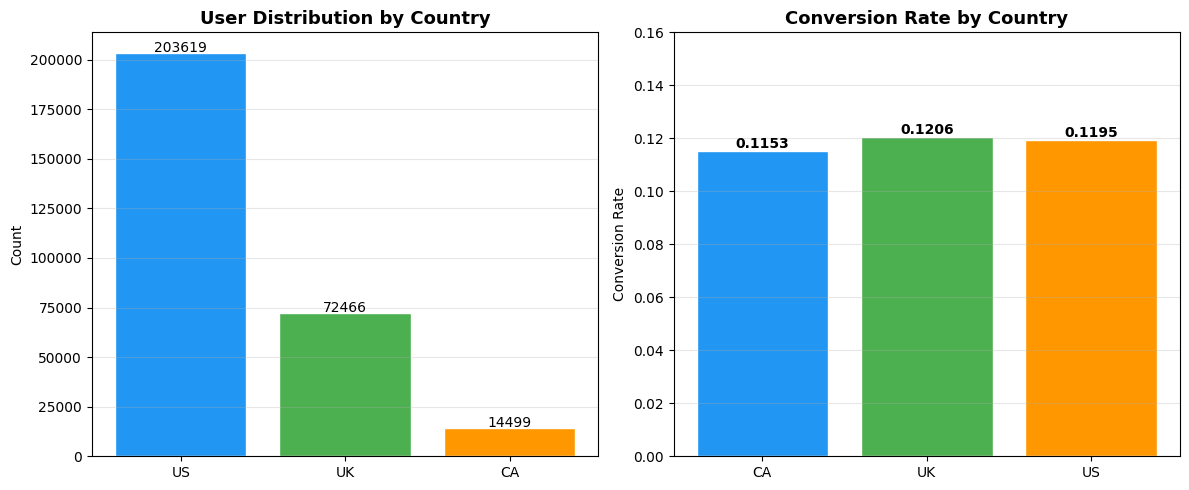

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cc = df_merged['country'].value_counts()
axes[0].bar(cc.index, cc.values, color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
axes[0].set_title('User Distribution by Country', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)

cv = df_merged.groupby('country')['converted'].mean()
axes[1].bar(cv.index, cv.values, color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
axes[1].set_title('Conversion Rate by Country', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Conversion Rate'); axes[1].set_ylim(0, 0.16); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(cv.values):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
X = df_merged[['ab_page', 'UK', 'US']].astype(float)
X = sm.add_constant(X)
y = df_merged['converted']

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=0)
print(result.summary2())

                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: converted        Pseudo R-squared: 0.000      
Date:               2026-05-20 15:47 AIC:              212781.1253
No. Observations:   290584           BIC:              212823.4439
Df Model:           3                Log-Likelihood:   -1.0639e+05
Df Residuals:       290580           LL-Null:          -1.0639e+05
Converged:          1.0000           LLR p-value:      0.17599    
No. Iterations:     6.0000           Scale:            1.0000     
--------------------------------------------------------------------
           Coef.    Std.Err.      z       P>|z|     [0.025    0.975]
--------------------------------------------------------------------
const     -2.0300     0.0266   -76.2488   0.0000   -2.0822   -1.9778
ab_page   -0.0149     0.0114    -1.3069   0.1912   -0.0374    0.0075
UK         0.0506     0.0284     1.7835   0.0745   -0.0050    0.1063
US       

In [14]:
# Interpret key coefficients
print(f'ab_page coef: {result.params["ab_page"]:.4f}  p={result.pvalues["ab_page"]:.4f}')
print(f'UK coef:      {result.params["UK"]:.4f}  p={result.pvalues["UK"]:.4f}')
print(f'US coef:      {result.params["US"]:.4f}  p={result.pvalues["US"]:.4f}')
print(f'Pseudo R2:    {result.prsquared:.4f}')
print('\nNone of the predictors are significant at alpha=0.05')

ab_page coefficient: -0.0149
ab_page p-value:     0.1912

Interpretation:
  - ab_page coef = -0.0149: treatment group has LOWER log-odds of conversion
  - p = 0.1912 > 0.05: NOT statistically significant

Country effects (reference: CA):
  UK: coef=0.0506, p=0.0745 — not significant
  US: coef=0.0408, p=0.1295 — not significant

Conclusion: Country does not moderate the ab_page effect.


---
## Part VI — Conclusions

### Summary of Evidence

| Method | Statistic | p-value | Conclusion |
|---|---|---|---|
| Simulation (10k runs) | diff = -0.0016 | 0.9029 | Fail to reject H₀ |
| Z-test (one-tailed) | z = -1.3109 | 0.9051 | Fail to reject H₀ |
| Logistic Regression | ab_page coef = -0.0149 | 0.1912 | Not significant |

### Recommendation

**Do NOT launch the new page.**

All three approaches — simulation, z-test, and logistic regression — consistently show **no statistically significant evidence** that the new page improves conversion rates (all p > 0.05).

The new page conversion rate (0.1188) is slightly **lower** than the old page (0.1204), a difference of 0.0016 percentage points. Country (US, UK, CA) does not moderate this effect.

**Recommendation:** Keep the old page. If the company wants to test further, run a redesigned variant with a more meaningful intervention before re-testing.

---
*Author: Sam Sepassi | nd588 Statistics for Data Analysis*


In [15]:
print('Analysis complete.')
print(f'Dataset: {len(df_clean):,} users | Control: {len(ctrl_df):,} | Treatment: {len(treat_df):,}')
print('All three methods agree: no significant evidence to launch new page.')

Analysis complete.
Dataset: 290,584 users | Control: 145,274 | Treatment: 145,310
All three methods agree: no significant evidence to launch new page.
